<a href="https://colab.research.google.com/github/Kay3132/Atari_Breakout_DeepQ/blob/main/examples/rl/ipynb/deep_q_network_breakout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Q-Learning for Atari Breakout

**Author:** [Jacob Chapman](https://twitter.com/jacoblchapman) and [Mathias Lechner](https://twitter.com/MLech20)<br>
**Date created:** 2020/05/23<br>
**Last modified:** 2024/03/16<br>
**Description:** Play Atari Breakout with a Deep Q-Network.

## Introduction

This script shows an implementation of Deep Q-Learning on the
`BreakoutNoFrameskip-v4` environment.

### Deep Q-Learning

As an agent takes actions and moves through an environment, it learns to map
the observed state of the environment to an action. An agent will choose an action
in a given state based on a "Q-value", which is a weighted reward based on the
expected highest long-term reward. A Q-Learning Agent learns to perform its
task such that the recommended action maximizes the potential future rewards.
This method is considered an "Off-Policy" method,
meaning its Q values are updated assuming that the best action was chosen, even
if the best action was not chosen.

### Atari Breakout

In this environment, a board moves along the bottom of the screen returning a ball that
will destroy blocks at the top of the screen.
The aim of the game is to remove all blocks and breakout of the
level. The agent must learn to control the board by moving left and right, returning the
ball and removing all the blocks without the ball passing the board.

### Note

The Deepmind paper trained for "a total of 50 million frames (that is, around 38 days of
game experience in total)". However this script will give good results at around 10
million frames which are processed in less than 24 hours on a modern machine.

You can control the number of episodes by setting the `max_episodes` variable
to a value greater than 0.

### References

- [Q-Learning](https://link.springer.com/content/pdf/10.1007/BF00992698.pdf)
- [Deep Q-Learning](https://www.semanticscholar.org/paper/Human-level-control-through-deep-reinforcement-Mnih-Kavukcuoglu/340f48901f72278f6bf78a04ee5b01df208cc508)

In [42]:
!pip install gymnasium[atari]
!pip install ale-py
!pip install shimmy
!pip install ale-py autorom

In [43]:
!AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


## Setup

In [51]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import gymnasium as gym
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
#from gymnasium.wrappers import AtariPreprocessing, FrameStack
import numpy as np
import tensorflow as tf

# Configuration parameters for the whole setup
seed = 42
gamma = 0.99  # Discount factor for past rewards
epsilon = 1.0  # Epsilon greedy parameter
epsilon_min = 0.1  # Minimum epsilon greedy parameter
epsilon_max = 1.0  # Maximum epsilon greedy parameter
epsilon_interval = (
    epsilon_max - epsilon_min
)  # Rate at which to reduce chance of random action being taken
batch_size = 32  # Size of batch taken from replay buffer
max_steps_per_episode = 10000
max_episodes = 100  # Limit training episodes, will run until solved if smaller than 1

# Use the Atari environment
# Specify the `render_mode` parameter to show the attempts of the agent in a pop up window.
import ale_py
gym.register_envs(ale_py)
env = gym.make("ALE/Breakout-v5", frameskip=1)
# Environment preprocessing
env = AtariPreprocessing(env)
# Stack four frames
env = FrameStackObservation(env, 4)
#env.seed(seed)

In [52]:
!pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.13.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.5
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         

## Implement the Deep Q-Network

This network learns an approximation of the Q-table, which is a mapping between
the states and actions that an agent will take. For every state we'll have four
actions, that can be taken. The environment provides the state, and the action
is chosen by selecting the larger of the four Q-values predicted in the output layer.

In [53]:
"""num_actions = 4


def create_q_model():
    # Network defined by the Deepmind paper
    return keras.Sequential(
        [
            layers.Lambda(
                lambda tensor: keras.ops.transpose(tensor, [0, 2, 3, 1]),
                output_shape=(84, 84, 4),
                input_shape=(4, 84, 84),
            ),
            # Convolutions on the frames on the screen
            layers.Conv2D(32, 8, strides=4, activation="relu", input_shape=(4, 84, 84)),
            layers.Conv2D(64, 4, strides=2, activation="relu"),
            layers.Conv2D(64, 3, strides=1, activation="relu"),
            layers.Flatten(),
            layers.Dense(512, activation="relu"),
            layers.Dense(num_actions, activation="linear"),
        ]
    )


# The first model makes the predictions for Q-values which are used to
# make a action.
model = create_q_model()
# Build a target model for the prediction of future rewards.
# The weights of a target model get updated every 10000 steps thus when the
# loss between the Q-values is calculated the target Q-value is stable.
model_target = create_q_model()"""
num_actions = 4

def create_q_model():
    inputs = layers.Input(shape=(4, 84, 84))
    x = layers.Lambda(lambda t: keras.ops.transpose(t, [0, 2, 3, 1]))(inputs)

    # 跟原版一樣的卷積層
    x = layers.Conv2D(32, 8, strides=4, activation="relu")(x)
    x = layers.Conv2D(64, 4, strides=2, activation="relu")(x)
    x = layers.Conv2D(64, 3, strides=1, activation="relu")(x)
    x = layers.Flatten()(x)

    shared = layers.Dense(512, activation="relu")(x)

    # Dueling: V(s) 流
    v = layers.Dense(256, activation="relu")(shared)
    V = layers.Dense(1)(v)

    # Dueling: A(s,a) 流
    a = layers.Dense(256, activation="relu")(shared)
    A = layers.Dense(num_actions)(a)

    # Q(s,a) = V(s) + (A(s,a) - mean(A))
    A_mean = layers.Lambda(lambda t: tf.reduce_mean(t, axis=1, keepdims=True))(A)
    Q = layers.Add()([V, layers.Subtract()([A, A_mean])])

    return keras.Model(inputs=inputs, outputs=Q)

model = create_q_model()
model_target = create_q_model()

## Train

In [54]:
# In the Deepmind paper they use RMSProp however then Adam optimizer
# improves training time
optimizer = keras.optimizers.Adam(learning_rate=0.00025, clipnorm=1.0)

# Experience replay buffers
action_history = []
state_history = []
state_next_history = []
rewards_history = []
done_history = []
episode_reward_history = []
running_reward = 0
episode_count = 0
frame_count = 0
# Number of frames to take random action and observe output
epsilon_random_frames = 5000
# Number of frames for exploration
epsilon_greedy_frames = 100000.0
# Maximum replay length
# Note: The Deepmind paper suggests 1000000 however this causes memory issues
max_memory_length = 50000
# Train the model after 4 actions
update_after_actions = 4
# How often to update the target network
update_target_network = 50000
# Using huber loss for stability
loss_function = keras.losses.Huber()

while True:
    #observation, _ = env.reset()
    observation, _ = env.reset(seed=seed)
    state = np.array(observation)
    episode_reward = 0

    for timestep in range(1, max_steps_per_episode):
        frame_count += 1

        # Use epsilon-greedy for exploration
        if frame_count < epsilon_random_frames or epsilon > np.random.rand(1)[0]:
            # Take random action
            action = np.random.choice(num_actions)
        else:
            # Predict action Q-values
            # From environment state
            state_tensor = keras.ops.convert_to_tensor(state)
            state_tensor = keras.ops.expand_dims(state_tensor, 0)
            action_probs = model(state_tensor, training=False)
            # Take best action
            action = keras.ops.argmax(action_probs[0]).numpy()

        # Decay probability of taking random action
        epsilon -= epsilon_interval / epsilon_greedy_frames
        epsilon = max(epsilon, epsilon_min)

        # Apply the sampled action in our environment
        state_next, reward, done, _, _ = env.step(action)
        state_next = np.array(state_next)

        episode_reward += reward

        # Save actions and states in replay buffer
        action_history.append(action)
        state_history.append(state)
        state_next_history.append(state_next)
        done_history.append(done)
        rewards_history.append(reward)
        state = state_next

        # Update every fourth frame and once batch size is over 32
        if frame_count % update_after_actions == 0 and len(done_history) > batch_size:
            # Get indices of samples for replay buffers
            indices = np.random.choice(range(len(done_history)), size=batch_size)

            # Using list comprehension to sample from replay buffer
            state_sample = np.array([state_history[i] for i in indices])
            state_next_sample = np.array([state_next_history[i] for i in indices])
            rewards_sample = [rewards_history[i] for i in indices]
            action_sample = [action_history[i] for i in indices]
            done_sample = keras.ops.convert_to_tensor(
                [float(done_history[i]) for i in indices]
            )
            '''
            # Build the updated Q-values for the sampled future states
            # Use the target model for stability
            future_rewards = model_target.predict(state_next_sample, verbose=0)
            # Q value = reward + discount factor * expected future reward
            updated_q_values = rewards_sample + gamma * keras.ops.amax(
                future_rewards, axis=1
            )
            '''
            # Double DQN: online 選動作，target 評估
            future_rewards_online = model(state_next_sample, training=False)
            best_actions = keras.ops.argmax(future_rewards_online, axis=1)
            future_rewards_target = model_target.predict(state_next_sample, verbose=0)
            best_action_mask = keras.ops.one_hot(best_actions, num_actions)
            updated_q_values = rewards_sample + gamma * keras.ops.sum(
                future_rewards_target * best_action_mask, axis=1
            )


            # If final frame set the last value to -1
            updated_q_values = updated_q_values * (1 - done_sample) - done_sample

            # Create a mask so we only calculate loss on the updated Q-values
            masks = keras.ops.one_hot(action_sample, num_actions)

            with tf.GradientTape() as tape:
                # Train the model on the states and updated Q-values
                q_values = model(state_sample)

                # Apply the masks to the Q-values to get the Q-value for action taken
                q_action = keras.ops.sum(keras.ops.multiply(q_values, masks), axis=1)
                # Calculate loss between new Q-value and old Q-value
                loss = loss_function(updated_q_values, q_action)

            # Backpropagation
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        if frame_count % update_target_network == 0:
            # update the the target network with new weights
            model_target.set_weights(model.get_weights())
            # Log details
            template = "running reward: {:.2f} at episode {}, frame count {}"
            print(template.format(running_reward, episode_count, frame_count))

        # Limit the state and reward history
        if len(rewards_history) > max_memory_length:
            del rewards_history[:1]
            del state_history[:1]
            del state_next_history[:1]
            del action_history[:1]
            del done_history[:1]

        if done:
            break

    # Update running reward to check condition for solving
    episode_reward_history.append(episode_reward)
    if len(episode_reward_history) > 100:
        del episode_reward_history[:1]
    running_reward = np.mean(episode_reward_history)

    # 自訂訓練log
    print(f"\rEpisode {episode_count + 1}/{max_episodes} | "
          f"Reward: {episode_reward:.0f} | "
          f"Running: {running_reward:.2f} | "
          f"Frames: {frame_count} | "
          f"ε: {epsilon:.3f}", end="")

    episode_count += 1

    if running_reward > 40:  # Condition to consider the task solved
        print("Solved at episode {}!".format(episode_count))
        break

    if (
        max_episodes > 0 and episode_count >= max_episodes
    ):  # Maximum number of episodes reached
        print("Stopped at episode {}!".format(episode_count))
        break

Episode 100/100 | Reward: 3 | Running: 1.07 | Frames: 17878 | ε: 0.839Stopped at episode 100!


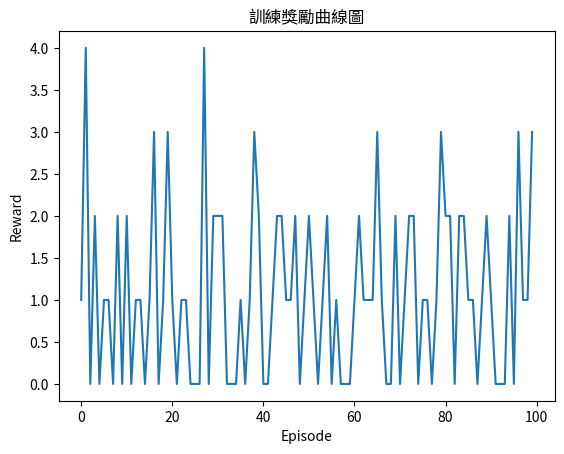

Running reward: 1.07, Episodes: 100, Frames: 17878


In [55]:
import matplotlib
import matplotlib.pyplot as plt

# 中文字型
!wget -q https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf -O /tmp/NotoSansCJKtc.otf

from matplotlib import font_manager
font_manager.fontManager.addfont('/tmp/NotoSansCJKtc.otf')
matplotlib.rc('font', family='Noto Sans CJK TC')

plt.plot(episode_reward_history)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('訓練獎勵曲線圖')
plt.show()
print(f"Running reward: {running_reward:.2f}, Episodes: {episode_count}, Frames: {frame_count}")

In [50]:
# 重置全部狀態
epsilon = 1.0
action_history = []
state_history = []
state_next_history = []
rewards_history = []
done_history = []
episode_reward_history = []
running_reward = 0
episode_count = 0
frame_count = 0

# 建立改良版模型（Dueling Head）
model = create_q_model()        # 這時 create_q_model 已經是改良版
model_target = create_q_model()
optimizer = keras.optimizers.Adam(learning_rate=0.00025, clipnorm=1.0)

# 然後跑一模一樣的訓練迴圈（裡面有 Double DQN 改動）

## Visualizations
Before any training:
![Imgur](https://i.imgur.com/rRxXF4H.gif)

In early stages of training:
![Imgur](https://i.imgur.com/X8ghdpL.gif)

In later stages of training:
![Imgur](https://i.imgur.com/Z1K6qBQ.gif)